In [1]:
import os
import pandas as pd
import pickle
from matplotlib import pyplot as plt
import numpy as np
from ribbn_scripts.processing.get_offset import get_offset
from ribbn_scripts.processing.phase_estimate import multidist_multifreq_phase_estimation
from ribbn_scripts.processing.localization import estimate_dph_df,direct_distance_estimate,estimate_k,unwrap_phases
from ribbn_scripts.ref_functions.spec_functions import read_network_analyzer_file, get_theta, get_amplitude, s2z
import pickle

In [2]:
df_all=None
file_names = sorted([f for f in os.listdir("dataframes") if f[0] != '.'], key=lambda x: int(x.split('.')[0]))
for file_name in file_names:
    exp_num=int(file_name.split(".")[0])
    with open(f'dataframes/{file_name}', "rb") as f:
        print(file_name)
        _df = pickle.load(f)
        # Add new columns to _df for all rows
        _df['Run Exp Num'] = exp_num
        if df_all is None:
            df_all=_df
        else:
            df_all = pd.concat([df_all, _df], ignore_index=True)

df_all

0.df
1.df
2.df
3.df
4.df
5.df
6.df
7.df
8.df
9.df
10.df
11.df
12.df
13.df
14.df
15.df


,Rx,Tx,MPP Start Time (s),MPP Stop Time (s),Voltages (mV),Frequency (MHz),Run Exp Num,NumMPPs
0,Tag1,Tag2,1.770760e+09,1.770760e+09,"[271.04, 145.99, 145.76, 145.76, 145.91, 145.8...",845,0,1
1,Tag2,Tag1,1.770760e+09,1.770760e+09,"[644.2, 484.21, 483.44, 483.37, 483.9, 483.98,...",845,0,1
2,Tag1,Tag2,1.770760e+09,1.770760e+09,"[151.03, 23.31, 23.31, 23.38, 23.0, 23.38, 23....",855,0,1
3,Tag2,Tag1,1.770760e+09,1.770760e+09,"[489.24, 313.31, 312.92, 313.08, 312.47, 313.6...",855,0,1
4,Tag1,Tag2,1.770760e+09,1.770760e+09,"[25.37, 248.84, 248.76, 248.68, 248.38, 249.07...",865,0,1
...,...,...,...,...,...,...,...,...
347,Tag2,Tag1,1.770762e+09,1.770762e+09,"[707.6, 560.43, 560.43, 560.81, 561.19, 562.33...",925,15,1
348,Tag1,Tag2,1.770762e+09,1.770762e+09,"[106.7, 138.06, 137.29, 137.14, 137.14, 137.9,...",935,15,1
349,Tag2,Tag1,1.770762e+09,1.770762e+09,"[580.8, 383.73, 384.41, 383.8, 383.73, 383.5, ...",935,15,1
350,Tag1,Tag2,1.770762e+09,1.770762e+09,"[145.38, 13.01, 13.16, 13.31, 13.31, 13.24, 13...",945,15,1


/var/folders/hm/7p8fzz2x2y10pbydpxcs7vw00000gn/T/ipykernel_6343/3615792023.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  processedDF=pd.concat([processedDF,pd.DataFrame([entry])],ignore_index=True)
/var/folders/hm/7p8fzz2x2y10pbydpxcs7vw00000gn/T/ipykernel_6343/3615792023.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  processedDF_aggregated=pd.concat([processedDF_aggregated, pd.DataFrame([entry_aggregated])], ignore_index=True)


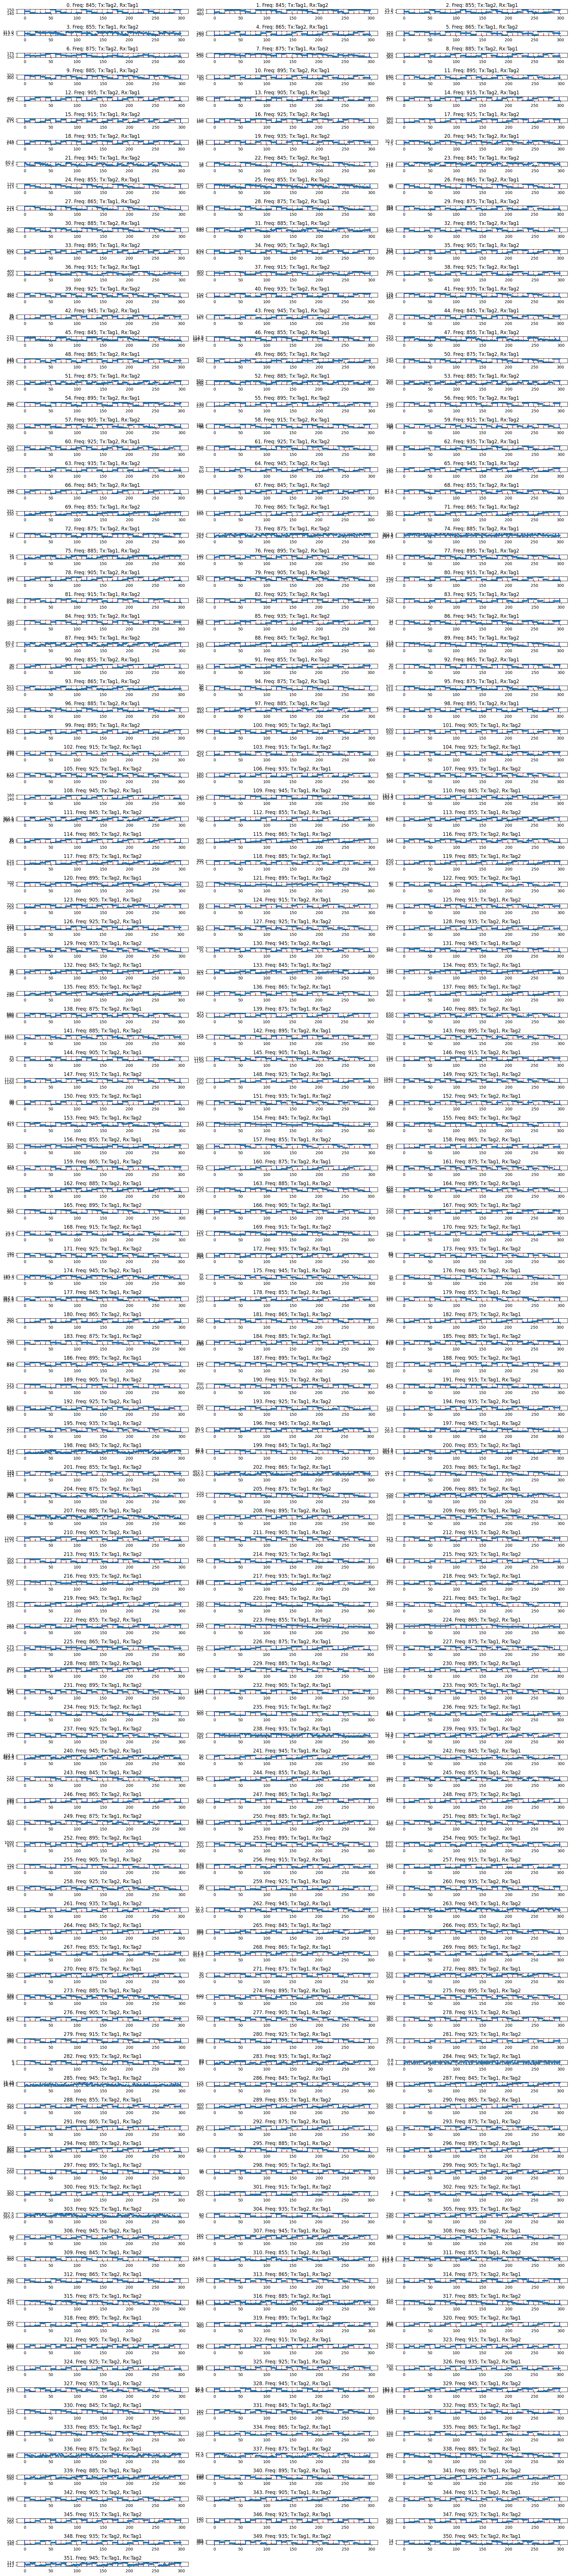

In [3]:
time_per_phase = 10/1000  # s
num_phases=6
default_MPPs=5
num_mpps=df_all.iloc[0]['NumMPPs']*default_MPPs
sampling_rate=1000
plotting=True
ver_lines = [0] + [ (time_per_phase-time_per_phase*0.01) * sampling_rate * (i + 1) for i in range(num_phases*num_mpps)]

processedDF=pd.DataFrame(columns=["Rx","Tx", "Voltages (mV)", "Phase1","Phase3","Phase4","Phase6","Phase7","Phase8",
                                "Frequency (MHz)", "Run Exp Num", "NumMPPs"])
processedDF_aggregated=pd.DataFrame(columns=["Rx","Tx","phase", "median", "std","freq", "dist", 'delta', "Experiment Number", "Unique Exp Number"])

if plotting:
    plt.figure(figsize=(20,90))

unique_exp_no=0
phase_order=[1,3,4,6,7,8]

for df_idx in range(len(df_all)):

    voltages=df_all.iloc[df_idx]['Voltages (mV)']
    phase_medians={
        1:[],
        3:[],
        4:[],
        6:[],
        7:[],
        8:[],
    }
    for idx,v in enumerate(ver_lines):
        if idx<len(ver_lines)-1:
            phase_medians[phase_order[int(idx%num_phases)]].append(np.median(voltages[int(ver_lines[idx]):int(ver_lines[idx+1])]))   
        if plotting:
            plt.subplot(len(df_all)//3+1, 3, df_idx+1)
            if idx%num_phases==0:
                plt.axvline(x=v, color='b', linestyle='-')
            else:
                plt.axvline(x=v, color='r', linestyle='--')
    
    for phase_out_idx in range(len(phase_medians[1])):
        entry={
            "Rx": df_all.iloc[df_idx]["Rx"],
            "Tx":df_all.iloc[df_idx]["Tx"],
            "Voltages (mV)":df_all.iloc[df_idx]["Voltages (mV)"],
            "Phase1":phase_medians[1][phase_out_idx],
            "Phase3":phase_medians[3][phase_out_idx],
            "Phase4":phase_medians[4][phase_out_idx],
            "Phase6":phase_medians[6][phase_out_idx],
            "Phase7":phase_medians[7][phase_out_idx],
            "Phase8":phase_medians[8][phase_out_idx],
            "Frequency (MHz)":df_all.iloc[df_idx]["Frequency (MHz)"],
            "Run Exp Num":df_all.iloc[df_idx]["Run Exp Num"],
            # "Tape Dist (m)":df_all.iloc[df_idx]["Tape dist"],
            # "Laser Dist (m)":df_all.iloc[df_idx]["Laser dist"],
            "Dist (m)":1.185,
            "NumMPPs":df_all.iloc[df_idx]["NumMPPs"],
        }
        processedDF=pd.concat([processedDF,pd.DataFrame([entry])],ignore_index=True)
        # print("Yo",phase_out_idx)
        # print(phase_medians)
        
    for phase in phase_order:
        entry_aggregated={
            "Rx":df_all.iloc[df_idx]["Rx"],
            "Tx":df_all.iloc[df_idx]["Tx"],
            "phase": str(phase),
            "median": np.mean(phase_medians[phase]), # mean of medians
            "std": np.std(phase_medians[phase]),
            "freq": df_all.iloc[df_idx]["Frequency (MHz)"]*1e6,
            "dist":1.185,
            'delta': max(phase_medians[phase])-min(phase_medians[phase]),
            "Experiment Number":df_all.iloc[df_idx]["Run Exp Num"],
            "Unique Exp Number":unique_exp_no,
            "allVoltages": phase_medians[phase]
        }
        processedDF_aggregated=pd.concat([processedDF_aggregated, pd.DataFrame([entry_aggregated])], ignore_index=True)
    unique_exp_no+=1
    
    # Identify and print bad MPPs
    # bad=False
    # for k in phase_medians.keys():
    #     assert(len(phase_medians[k])==num_mpps)
    #     if np.std(phase_medians[k])>1:
    #         d=1.185
    #         print(f"<== Bad data found at {df_idx} df_idx at phase {k} at T2T dist {d}.", end="\t")
    #         print(f"Num vals: {len(phase_medians[k])}, mean: {np.mean(phase_medians[k])}, stdev: {np.std(phase_medians[k])} ==>")
    
    if plotting:
        plt.plot(voltages,'.')
        plt.title(f'{df_idx}. Freq: {df_all.iloc[df_idx]["Frequency (MHz)"]}; Tx:{df_all.iloc[df_idx]["Tx"]}, Rx:{df_all.iloc[df_idx]["Rx"]}')
        plt.ylim([np.percentile(voltages, 1), np.percentile(voltages, 99)])
        plt.tight_layout()
    # break
if plotting:
    plt.savefig("MPPs.pdf")
    

    

In [4]:
with open("processedDF.pkl", 'wb') as f:
    pickle.dump(processedDF,f)
processedDF

,Rx,Tx,Voltages (mV),Phase1,Phase3,Phase4,Phase6,Phase7,Phase8,Frequency (MHz),Run Exp Num,NumMPPs,Dist (m)
0,Tag1,Tag2,"[271.04, 145.99, 145.76, 145.76, 145.91, 145.8...",145.91,141.830,139.695,139.850,141.110,151.065,845,0,1,1.185
1,Tag1,Tag2,"[271.04, 145.99, 145.76, 145.76, 145.91, 145.8...",145.76,141.985,140.000,139.470,141.340,150.990,845,0,1,1.185
2,Tag1,Tag2,"[271.04, 145.99, 145.76, 145.76, 145.91, 145.8...",146.03,142.060,139.850,139.580,141.340,151.065,845,0,1,1.185
3,Tag1,Tag2,"[271.04, 145.99, 145.76, 145.76, 145.91, 145.8...",145.84,141.870,139.810,139.510,141.300,150.990,845,0,1,1.185
4,Tag1,Tag2,"[271.04, 145.99, 145.76, 145.76, 145.91, 145.8...",145.84,141.755,139.730,139.695,141.300,151.100,845,0,1,1.185
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1755,Tag2,Tag1,"[372.74, 113.03, 112.65, 112.27, 112.27, 112.5...",112.65,113.335,111.620,111.850,112.535,113.180,945,15,1,1.185
1756,Tag2,Tag1,"[372.74, 113.03, 112.65, 112.27, 112.27, 112.5...",112.69,113.375,111.350,111.890,112.500,113.340,945,15,1,1.185
1757,Tag2,Tag1,"[372.74, 113.03, 112.65, 112.27, 112.27, 112.5...",112.95,113.605,111.695,112.190,112.840,113.490,945,15,1,1.185
1758,Tag2,Tag1,"[372.74, 113.03, 112.65, 112.27, 112.27, 112.5...",113.34,113.715,112.120,112.155,112.840,113.605,945,15,1,1.185


In [5]:
processedDF_aggregated

,Rx,Tx,phase,median,std,freq,dist,delta,Experiment Number,Unique Exp Number,allVoltages
0,Tag1,Tag2,1,145.876,0.090465,845000000.0,1.185,0.270,0,0,"[145.91, 145.76, 146.03, 145.84, 145.84]"
1,Tag1,Tag2,3,141.900,0.109225,845000000.0,1.185,0.305,0,0,"[141.82999999999998, 141.985, 142.06, 141.87, ..."
2,Tag1,Tag2,4,139.817,0.106846,845000000.0,1.185,0.305,0,0,"[139.695, 140.0, 139.85, 139.81, 139.73]"
3,Tag1,Tag2,6,139.621,0.137637,845000000.0,1.185,0.380,0,0,"[139.85, 139.47, 139.58, 139.51, 139.695]"
4,Tag1,Tag2,7,141.278,0.085884,845000000.0,1.185,0.230,0,0,"[141.11, 141.34, 141.34, 141.3, 141.3]"
...,...,...,...,...,...,...,...,...,...,...,...
2107,Tag2,Tag1,3,113.626,0.275942,945000000.0,1.185,0.765,15,351,"[113.33500000000001, 113.375, 113.604999999999..."
2108,Tag2,Tag1,4,111.750,0.269462,945000000.0,1.185,0.770,15,351,"[111.62, 111.35, 111.695, 112.12, 111.965]"
2109,Tag2,Tag1,6,112.048,0.146445,945000000.0,1.185,0.340,15,351,"[111.85, 111.89, 112.19, 112.155, 112.155]"
2110,Tag2,Tag1,7,112.726,0.172783,945000000.0,1.185,0.415,15,351,"[112.535, 112.5, 112.84, 112.84, 112.914999999..."


In [6]:
# freq_range=np.array(range(775,1000,10))*1e6
# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, all_errors, \
#     selected_experiments_all = multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=0,plot=True)

# with open("no_correction_all_errs.pkl",'wb') as f:
#     pickle.dump(all_errors,f)
    
# with open("no_correction_all_phases.pkl",'wb') as f:
#     pickle.dump(all_freqs,f)

# with open("no_correction_all_phases_unwrapped.pkl",'wb') as f:
#     pickle.dump(all_freqs_unwrapped,f)    

# with open("theoretical_phase.pkl",'wb') as f:
#     pickle.dump(all_freqs_theoretical,f)    

### With offset correction using the ground truth.

In [7]:
# correction_offsets={}
# all_errors=None


# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, _,_=\
#     multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=0,plot=False)


# for freq in freq_range:
#     offset,best_error,errors=get_offset(all_freqs[freq],freq)
#     # print(f"Freq {freq//1e6};\t Mean:{np.mean(errors)};\t Median:{np.median(errors)};\t Std:{np.std(errors)}")
#     # if all_errors is None:
#     #     all_errors=errors
#     # else:
#     #     all_errors=np.concat((all_errors,errors))
#     correction_offsets[freq]=offset



# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, all_errors,_=\
#     multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=correction_offsets,plot=True)


# with open("gt_correction_all_errs.pkl",'wb') as f:
#     pickle.dump(all_errors,f)
    
# with open("gt_correction_all_phases.pkl",'wb') as f:
#     pickle.dump(all_freqs,f)

# with open("gt_correction_all_phases_unwrapped.pkl",'wb') as f:
#     pickle.dump(all_freqs_unwrapped,f)    

### With correction offsets from pretrained

In [8]:
# correction_offsets=pickle.load(open("/Users/manavjeet/git/T2TExperiments/DistExperiments/correction_offsets.pkl",'rb'))

# all_freqs, all_freqs_unwrapped, all_freqs_theoretical, all_freqs_theoretical_unwrapped, all_errors,_=\
#     multidist_multifreq_phase_estimation(freq_range,processedDF_aggregated,correction_factor=correction_offsets,plot=True)


# with open("pretrained_correction_all_errs.pkl",'wb') as f:
#     pickle.dump(all_errors,f)
    
# with open("pretrained_correction_all_phases.pkl",'wb') as f:
#     pickle.dump(all_freqs,f)

# with open("pretrained_correction_all_phases_unwrapped.pkl",'wb') as f:
#     pickle.dump(all_freqs_unwrapped,f)